## 1. Setup and Actuarial Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Financial Configuration ---
risk_free_rate = 0.02  
valuation_age = 65
max_age = 95
time_horizon = max_age - valuation_age

def get_discount_factors(rate, horizon):
    t = np.arange(1, horizon + 1)
    return np.exp(-rate * t)

def calculate_tp_x(mx_path):
    px = np.exp(-mx_path)
    tp_x = np.concatenate(([1.0], np.cumprod(px)))
    return tp_x

def compute_annuity_pv(tp_x, discount_factors):
    # Present Value of 1 CHF paid at the end of each year
    return np.sum(tp_x[1:] * discount_factors[:len(tp_x)-1])

print(f"Setup complete. Valuation Age: {valuation_age} | Rate: {risk_free_rate*100}%")

Setup complete. Valuation Age: 65 | Rate: 2.0%


## 2. Data Recovery and Parameter Extraction

In [2]:
# --- Loading raw data ---
def load_hmd_mx(filepath):
    df = pd.read_csv(filepath, skiprows=2, sep='\s+')
    df['Age'] = df['Age'].astype(str).str.replace('+', '', regex=False).astype(int)
    for col in ['Female', 'Male', 'Total']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['Total'])

# Load and prepare log_mx matrix
df = load_hmd_mx('../data/Mx_1x1.txt')
df_clean = df[(df['Year'] >= 1950) & (df['Age'] <= 95)].copy()
mx_matrix = df_clean.pivot(index='Age', columns='Year', values='Total').replace(0, 1e-8)
log_mx = np.log(mx_matrix)
years = mx_matrix.columns

# --- Re-calculating Lee-Carter Parameters ---
alpha_x = log_mx.mean(axis=1)
Z = log_mx.sub(alpha_x, axis=0)
U, S, Vh = np.linalg.svd(Z, full_matrices=False)
bx = U[:, 0] / U[:, 0].sum()
kt = Vh[0, :] * S[0] * U[:, 0].sum()
if kt[0] < kt[-1]: kt, bx = -kt, -bx

# --- Re-calculating Forecast & Simulations ---
drift = np.mean(np.diff(kt))
sigma = np.std(np.diff(kt))
n_years = 2050 - years[-1]
last_kt = kt[-1]

np.random.seed(42)
kt_forecast = last_kt + drift * (np.arange(1, n_years + 1))
simulations = np.zeros((1000, n_years))
for i in range(1000):
    innovations = np.random.normal(0, sigma, n_years)
    simulations[i, :] = last_kt + np.cumsum(drift + innovations)

print(f"Data and Parameters recovered successfully for {len(years)} years.")

Data and Parameters recovered successfully for 75 years.


## 3. Mortality Projection and Stress Scenario Calculation

In [3]:
# Best Estimate vs Stress (99.5th longevity percentile)
kt_be = kt_forecast[:time_horizon]
kt_stress = np.percentile(simulations, 0.5, axis=0)[:time_horizon]

def project_mx_path(kt_path, alpha, beta, start_age):
    mx_path = []
    for t, kt_val in enumerate(kt_path):
        age = start_age + t
        log_mx = alpha[age] + beta[age] * kt_val
        mx_path.append(np.exp(log_mx))
    return np.array(mx_path)

# Project mx paths for a 65-year old
mx_be = project_mx_path(kt_be, alpha_x, bx, valuation_age)
mx_stress = project_mx_path(kt_stress, alpha_x, bx, valuation_age)

# Compute Survival Curves and Annuity PVs
df_factors = get_discount_factors(risk_free_rate, time_horizon)
surv_be = calculate_tp_x(mx_be)
surv_stress = calculate_tp_x(mx_stress)

pv_be = compute_annuity_pv(surv_be, df_factors)
pv_stress = compute_annuity_pv(surv_stress, df_factors)
scr_loading = (pv_stress - pv_be) / pv_be * 100

print(f"Annuity PV (BE): {pv_be:.4f}")
print(f"Annuity PV (Stress 99.5%): {pv_stress:.4f}")
print(f"Longevity SCR Loading: {scr_loading:.2f}%")

Annuity PV (BE): 16.6061
Annuity PV (Stress 99.5%): 17.2603
Longevity SCR Loading: 3.94%


## 4. Visualizing the Longevity Shock

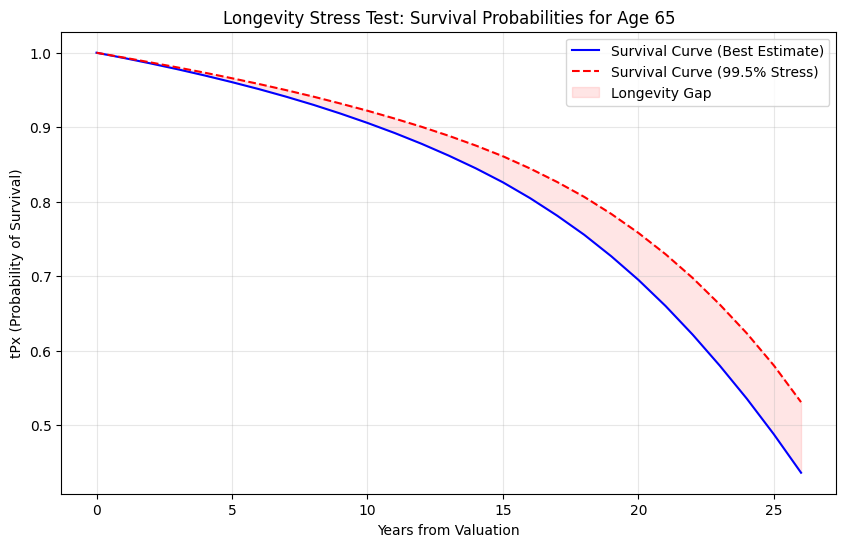

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(surv_be)), surv_be, label='Survival Curve (Best Estimate)', color='blue')
plt.plot(np.arange(len(surv_stress)), surv_stress, label='Survival Curve (99.5% Stress)', color='red', linestyle='--')
plt.fill_between(np.arange(len(surv_be)), surv_be, surv_stress, color='red', alpha=0.1, label='Longevity Gap')

plt.title(f'Longevity Stress Test: Survival Probabilities for Age {valuation_age}')
plt.xlabel('Years from Valuation')
plt.ylabel('tPx (Probability of Survival)')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('../reports/figures/08_longevity_stress_test.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Backtesting Implementation

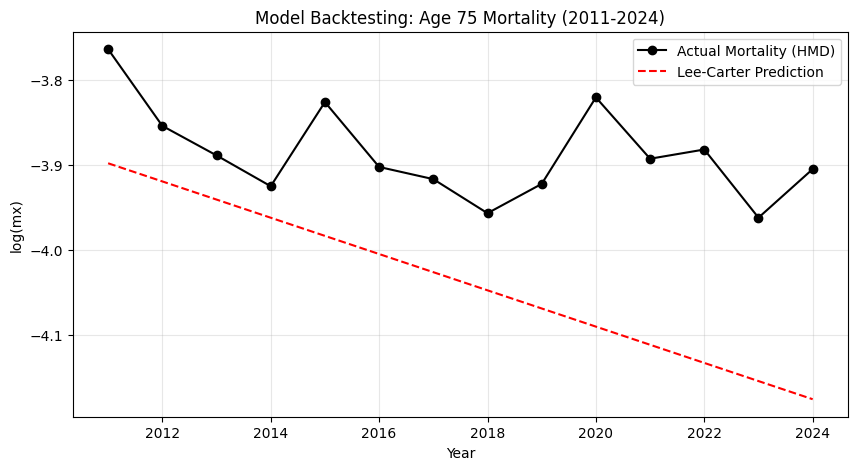

Backtest RMSE for Age 75: 0.1682


In [5]:
# --- Model Backtesting: Train (1950-2010) vs Test (2011-2024) ---

# 1. Data Split
split_year = 2010
train_matrix = log_mx.loc[:, :split_year]
test_matrix = log_mx.loc[:, split_year+1:]
test_years = test_matrix.columns

# 2. Fit Lee-Carter on Training Data
alpha_train = train_matrix.mean(axis=1)
Z_train = train_matrix.sub(alpha_train, axis=0)
U, S, Vh = np.linalg.svd(Z_train, full_matrices=False)
bx_train = U[:, 0] / U[:, 0].sum()
kt_train = Vh[0, :] * S[0] * U[:, 0].sum()
if kt_train[0] < kt_train[-1]: kt_train, bx_train = -kt_train, -bx_train

# 3. Forecast kt for the test period
drift_train = np.mean(np.diff(kt_train))
last_kt_train = kt_train[-1]
kt_pred = last_kt_train + drift_train * np.arange(1, len(test_years) + 1)

# 4. Compare Prediction vs Actual for Age 75
age_sample = 75
actual_log_mx = test_matrix.loc[age_sample, :].values
pred_log_mx = alpha_train[age_sample] + bx_train[age_sample] * kt_pred

# 5. Visualization
plt.figure(figsize=(10, 5))
plt.plot(test_years, actual_log_mx, 'ko-', label='Actual Mortality (HMD)')
plt.plot(test_years, pred_log_mx, 'r--', label='Lee-Carter Prediction')

plt.title(f'Model Backtesting: Age {age_sample} Mortality (2011-2024)')
plt.xlabel('Year')
plt.ylabel('log(mx)')
plt.legend()
plt.grid(alpha=0.3)

# Save directly within the cell
plt.savefig('../reports/figures/09_backtesting_age75.png', dpi=300, bbox_inches='tight')
plt.show()

# Quick Error Metric
rmse = np.sqrt(np.mean((actual_log_mx - pred_log_mx)**2))
print(f"Backtest RMSE for Age {age_sample}: {rmse:.4f}")